# Clickstream (Web Analytics) Generator

The ClickstreamGenerator simulates web analytics data including sessions, pageviews, conversions, bounces, and bot traffic. It supports multiple traffic sources and configurable seasonality patterns.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import ClickstreamGenerator

## Session Counts (1 Week Hourly)

Generate hourly session data for 3 series with mixed traffic sources, bot detection, and conversion tracking.

In [ ]:
params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "base_sessions": 500,
    "traffic_source": "mixed",
    "conversion_rate": 0.03,
    "bounce_rate": 0.40,
    "include_seasonality": True,
    "include_bots": True,
    "bot_fraction": 0.15,
    "output_type": "sessions",
    "seed": 42,
}

generator = ClickstreamGenerator(engine="polars", **params)
df = generator.generate(n_series=3)

print(f"Generated {df['unique_id'].n_unique()} time series")
print(f"Total hourly observations: {len(df)}")

stats = df.group_by("unique_id").agg(
    [
        pl.col("y").sum().alias("total_sessions"),
        pl.col("y").mean().alias("avg_per_hour"),
        pl.col("y").max().alias("peak_hour"),
    ]
)
stats

Generated 3 time series
Total hourly observations: 504


unique_id,total_sessions,avg_per_hour,peak_hour
cat,f64,f64,f64
"""2""",100944.0,600.857143,1218.0
"""0""",97521.0,580.482143,1246.0
"""1""",97112.0,578.047619,1149.0


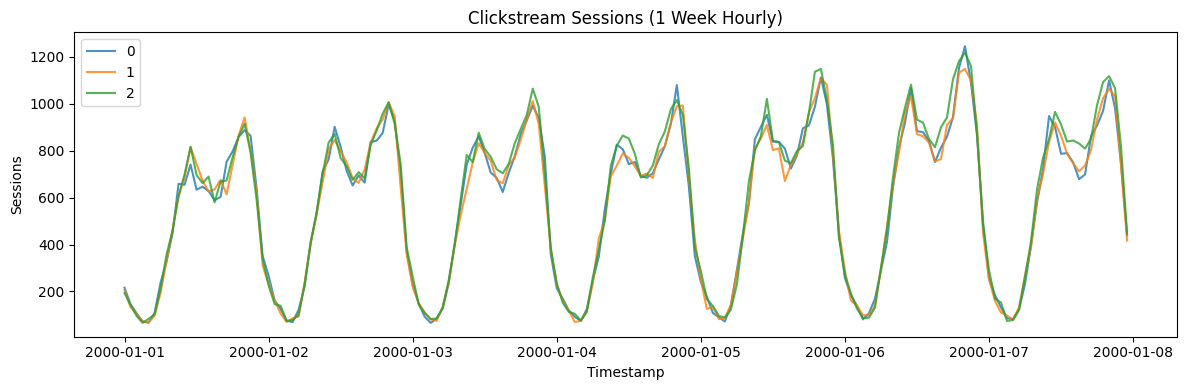

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Sessions")
ax.set_title("Clickstream Sessions (1 Week Hourly)")
ax.legend()
plt.tight_layout()
plt.show()

## Traffic Source Comparison

Compare conversion rates across different traffic sources: organic, paid, direct, and referral.

In [ ]:
sources = ["organic", "paid", "direct", "referral"]
for source in sources:
    gen = ClickstreamGenerator(engine="polars", 
        **{
            "min_length": 168,
            "max_length": 168,
            "freq": "h",
            "base_sessions": 500,
            "traffic_source": source,
            "output_type": "conversions",
            "seed": 42,
        }
    )
    source_df = gen.generate(n_series=1)
    conv_total = source_df["y"].sum()

    gen_sessions = ClickstreamGenerator(engine="polars", 
        **{
            "min_length": 168,
            "max_length": 168,
            "freq": "h",
            "base_sessions": 500,
            "traffic_source": source,
            "output_type": "sessions",
            "seed": 42,
        }
    )
    session_df = gen_sessions.generate(n_series=1)
    session_total = session_df["y"].sum()

    conv_rate = conv_total / session_total * 100 if session_total > 0 else 0
    print(
        f"{source:10s}: {session_total:,.0f} sessions, {conv_total:,.0f} conversions ({conv_rate:.2f}%)"
    )

organic   : 97,521 sessions, 2,083 conversions (2.14%)
paid      : 97,602 sessions, 2,715 conversions (2.78%)
direct    : 97,507 sessions, 3,576 conversions (3.67%)
referral  : 97,833 sessions, 1,065 conversions (1.09%)


## Complete Metrics

Generate a full set of web analytics metrics including sessions, pageviews, conversions, bounces, and derived rates.

In [ ]:
full_metrics = generator.generate_full_metrics(n_series=1)

print(f"Total sessions: {full_metrics['sessions'].sum():,.0f}")
print(f"Total pageviews: {full_metrics['pageviews'].sum():,.0f}")
print(f"Total conversions: {full_metrics['conversions'].sum():,.0f}")
print(f"Total bounces: {full_metrics['bounces'].sum():,.0f}")
print(f"Avg bounce rate: {full_metrics['bounce_rate'].mean() * 100:.1f}%")
print(f"Avg conversion rate: {full_metrics['conversion_rate'].mean() * 100:.2f}%")
print(f"Avg pages/session: {full_metrics['pages_per_session'].mean():.2f}")

Total sessions: 101,797
Total pageviews: 293,073
Total conversions: 1,531
Total bounces: 34,682
Avg bounce rate: 34.1%
Avg conversion rate: 1.52%
Avg pages/session: 2.89


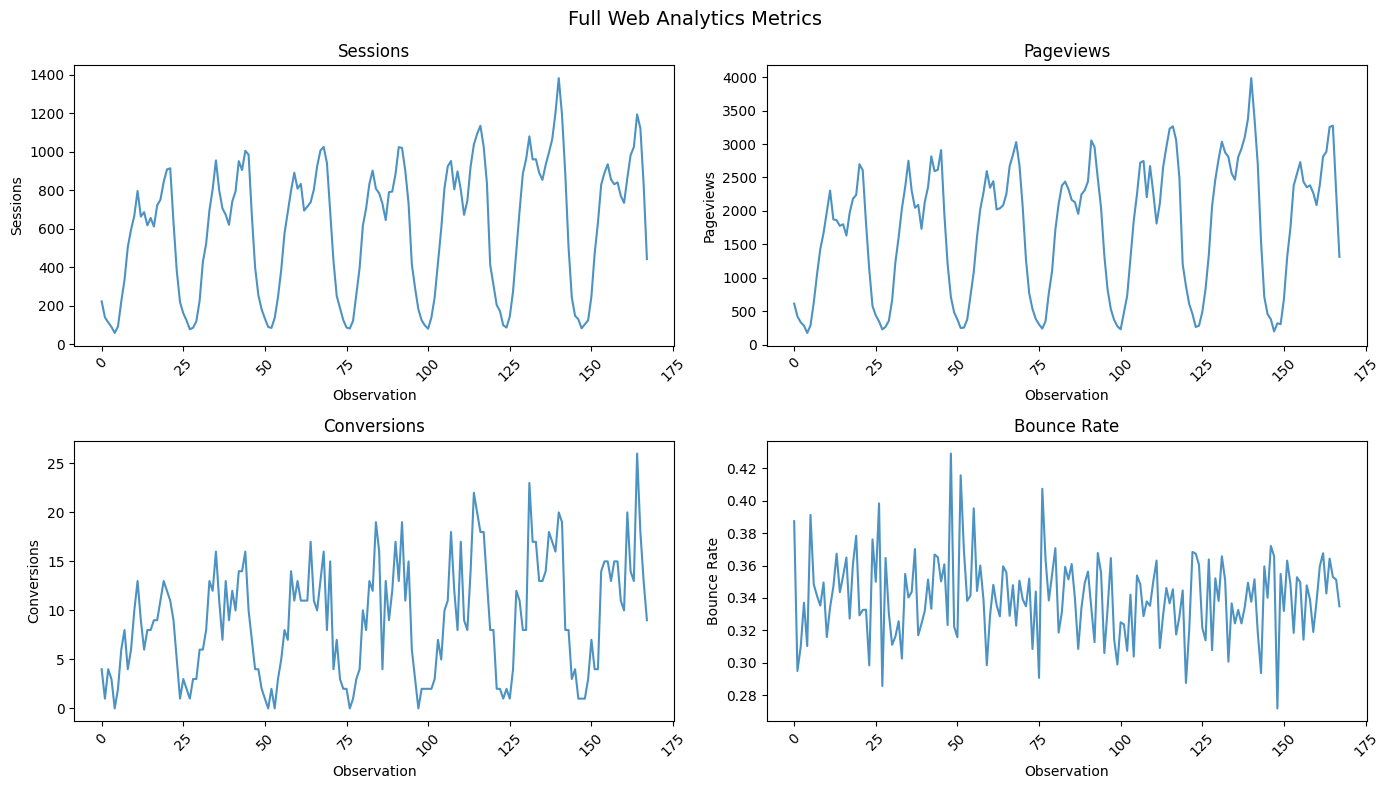

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metrics = [("sessions", "Sessions"), ("pageviews", "Pageviews"), ("conversions", "Conversions"), ("bounce_rate", "Bounce Rate")]
for ax, (col, title) in zip(axes.flat, metrics):
    ax.plot(full_metrics[col], alpha=0.8)
    ax.set_xlabel("Observation")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Full Web Analytics Metrics", fontsize=14)
plt.tight_layout()
plt.show()

## Conversion Funnel

Simulate a conversion funnel with 10,000 sessions to see drop-off rates at each stage.

In [ ]:
funnel = generator.generate_funnel(n_sessions=10000)

print("Stage                | Count    | Rate")
print("-" * 45)
prev_count = None
for stage, count in funnel.items():
    if prev_count is None:
        rate = 100.0
    else:
        rate = count / prev_count * 100
    print(f"{stage:20s} | {count:8,d} | {rate:5.1f}%")
    prev_count = count

overall_conv = funnel[list(funnel.keys())[-1]] / funnel["visit"] * 100
print(f"\nOverall funnel conversion: {overall_conv:.2f}%")

Stage                | Count    | Rate
---------------------------------------------
visit                |   10,000 | 100.0%
product_view         |    4,680 |  46.8%
add_to_cart          |    1,899 |  40.6%
checkout_start       |    1,201 |  63.2%
checkout_complete    |      905 |  75.4%

Overall funnel conversion: 9.05%


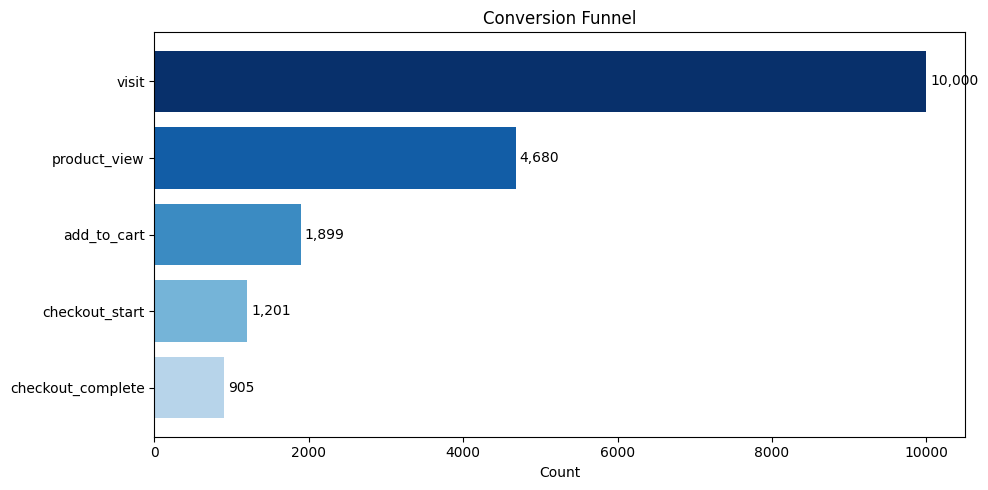

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
stages = list(funnel.keys())
counts = list(funnel.values())
bars = ax.barh(stages[::-1], counts[::-1], color=plt.cm.Blues(
    [0.3 + 0.7 * i / (len(stages) - 1) for i in range(len(stages))]
))
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2, f"{count:,}", va="center")
ax.set_xlabel("Count")
ax.set_title("Conversion Funnel")
plt.tight_layout()
plt.show()

## Hour-of-Day Pattern

Analyze the average session count by hour of day over 4 weeks to reveal the daily traffic pattern.

In [ ]:
hourly_gen = ClickstreamGenerator(engine="polars", 
    **{
        "min_length": 168 * 4,
        "max_length": 168 * 4,
        "freq": "h",
        "base_sessions": 1000,
        "include_seasonality": True,
        "include_bots": False,
        "seed": 42,
    }
)
hourly_df = hourly_gen.generate(n_series=1)

sessions = hourly_df["y"].to_numpy()
hourly_avg = [sessions[i::24].mean() for i in range(24)]

print("Hour | Avg Sessions | Relative")
print("-" * 35)
mean_hourly = sum(hourly_avg) / 24
for hour, avg in enumerate(hourly_avg):
    relative = avg / mean_hourly
    bar = "*" * int(relative * 10)
    print(f"  {hour:02d} |    {avg:7.1f}  | {bar}")

Hour | Avg Sessions | Relative
-----------------------------------
  00 |      364.1  | ****
  01 |      247.8  | **
  02 |      182.5  | **
  03 |      126.5  | *
  04 |      125.5  | *
  05 |      180.3  | **
  06 |      370.1  | ****
  07 |      611.0  | ******
  08 |      849.5  | *********
  09 |     1102.0  | ************
  10 |     1209.0  | *************
  11 |     1337.9  | ***************
  12 |     1216.2  | *************
  13 |     1157.9  | *************
  14 |     1100.3  | ************
  15 |     1047.2  | ***********
  16 |     1093.8  | ************
  17 |     1217.2  | *************
  18 |     1339.8  | ***************
  19 |     1470.6  | ****************
  20 |     1579.6  | *****************
  21 |     1452.0  | ****************
  22 |     1090.0  | ************
  23 |      615.1  | *******


## Model Information

Inspect the generator's configuration and parameters.

In [ ]:
info = generator.get_model_info()
for key, value in info.items():
    if key != "source_params":
        print(f"{key}: {value}")

base_sessions: 500.0
traffic_source: mixed
conversion_rate: 0.03
bounce_rate: 0.4
avg_session_depth: 3.5
include_seasonality: True
include_bots: True
bot_fraction: 0.15
output_type: sessions
